In [1]:
!pip install qiskit==2.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 15.0 MB/s eta 0:00:00


In [2]:
!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 76.1 MB/s eta 0:00:00


In [3]:
!pip install pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=d5240e96acdf807c89e066f995fdd2da4c8323d825388aba42517e7bed8c35d4
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [4]:
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister, transpile
from qiskit_aer import AerSimulator
import numpy as np

In [5]:
alpha = 1/np.sqrt(2)
beta  = 1/np.sqrt(2)

In [6]:
q = QuantumRegister(4, "q")
c = ClassicalRegister(3, "c")
qc = QuantumCircuit(q, c, name="HBB99_QSS")

In [7]:
qc.initialize([alpha, beta], q[0])

In [8]:
#GHZ state
qc.h(q[1])
qc.cx(q[1], q[2])
qc.cx(q[1], q[3])

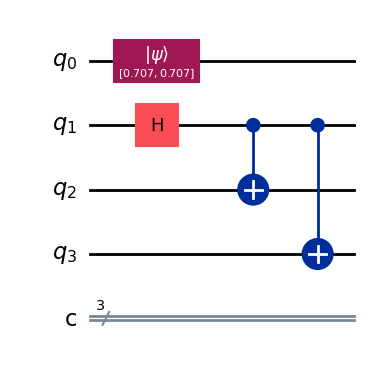

In [9]:
qc.draw('mpl')

In [10]:
#Alice encodes secret onto GHZ: CNOT S->A, then H on S
qc.cx(q[0], q[1])
qc.h(q[0])

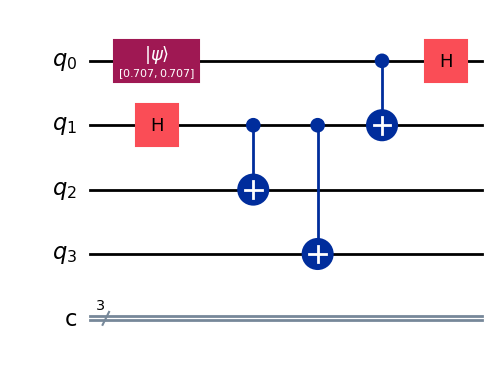

In [11]:
qc.draw('mpl')

In [12]:
qc.measure(q[0], c[0])   # m bit
qc.measure(q[1], c[1])   # a bit

In [13]:
# CONDITIONAL CORRECTIONS
# If a == 1 → value 2
with qc.if_test((c, 2)):
    qc.x(q[2])
    qc.x(q[3])

# If m == 1 → value 1
with qc.if_test((c, 1)):
    qc.z(q[2])

In [14]:
#Recovering the secret on q2 by applying CNOT(q2->q3). This maps alpha|00> + beta|11> -> (alpha|0> + beta|1>) ⊗ |0>
qc.cx(q[2], q[3])


In [15]:
qc.measure(q[2], c[2])

In [16]:
sim = AerSimulator()
tqc = transpile(qc, sim)
job = sim.run(tqc, shots=4096)
result = job.result()
counts = result.get_counts()

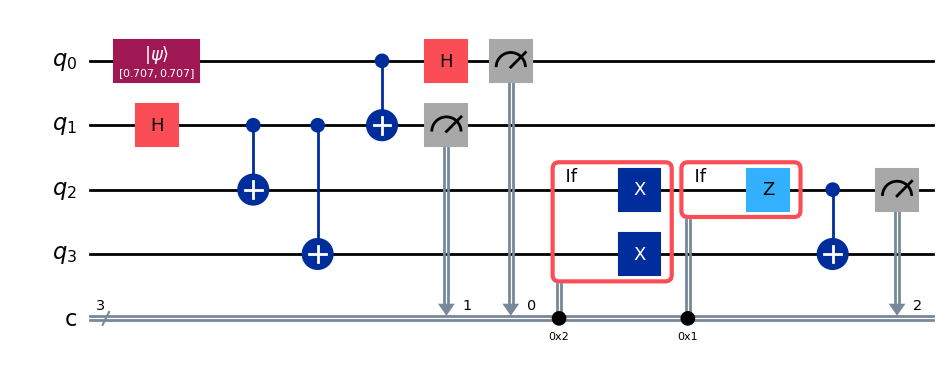

In [17]:
qc.draw('mpl')

In [18]:
print("\nReconstructed secret values:")
for bitstr, cnt in sorted(counts.items(), key=lambda x: -x[1]):
    reconstructed = bitstr[0]   # leftmost bit = c2
    print(f"secret={reconstructed},  count={cnt}")


Reconstructed secret values:
secret=0,  count=527
secret=0,  count=525
secret=1,  count=523
secret=0,  count=522
secret=1,  count=509
secret=0,  count=502
secret=1,  count=495
secret=1,  count=493
